In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
np.random.seed(0)
class Icing_model:
    def __init__(self,N,J,h):
        self.configuration = np.random.choice([-1,1],(N,1))
        self.N  = N
        self.J = J
        self.h = h
        
    def Energy(self,config):
        config = config.flatten() 
        E = np.dot(config[:-1],config[1:]) + config[-1] * config[0]
        E = np.float64(-E * self.J)
        E -= np.float64(np.sum(config) * self.h)
        return E
    def update_config(self):
        i = np.random.choice(range(0,self.N))
        new_config = np.copy(self.configuration)
        new_config[i] *= -1
        
        old_energy = self.Energy(self.configuration)
        new_energy = self.Energy(new_config)
        if new_energy < old_energy:
            self.configuration = new_config
        else:
            change_in_E = new_energy - old_energy
            p = np.exp(-change_in_E)
            p1 = np.random.rand()
            if p1 < p:
                self.configuration = new_config
            else:
                return

    def simulate(self,steps):
        self.steps = steps
        self.energy_vs_steps = np.zeros((steps,1))
        for n in range(steps):
            for i in range(self.N):
                self.update_config()
            self.energy_vs_steps[n] = self.Energy(self.configuration)
        return self.configuration
    def plot_energy_vs_steps(self):
        plt.plot(range(self.steps),self.energy_vs_steps,label=f"J:{self.J},h:{self.h}")       
        
    

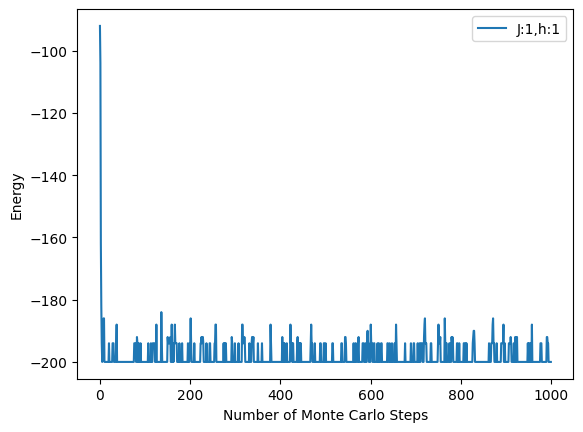

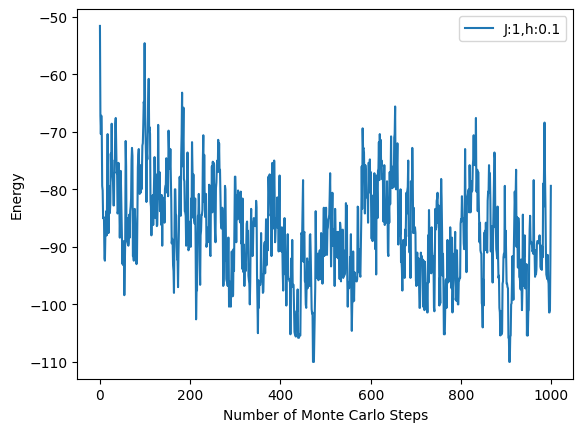

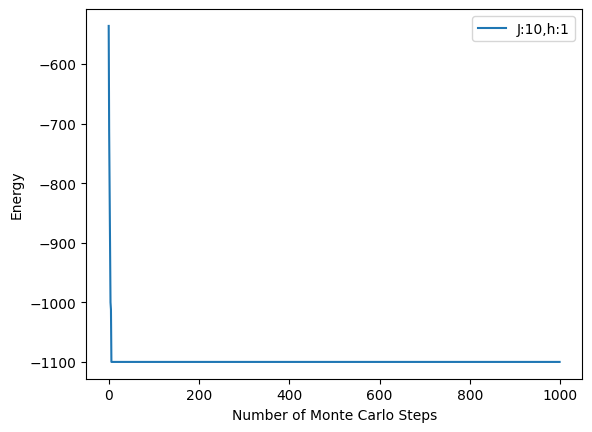

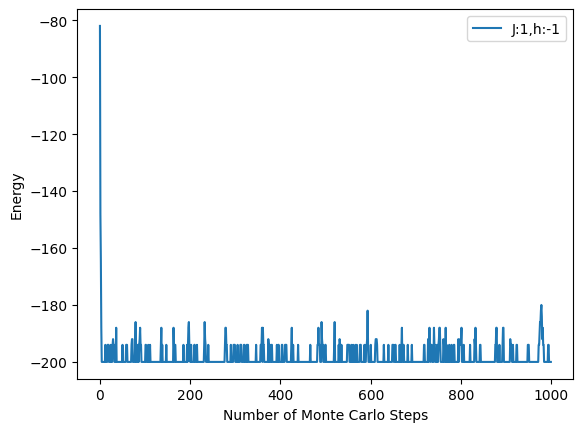

In [33]:
tup = ((1,1), (1, 0.1), (10, 1), (1,-1))

for (J,h) in tup:
    monte_carlo = Icing_model(100,J,h)
    monte_carlo.simulate(1000)
    monte_carlo.plot_energy_vs_steps()
    plt.xlabel("Number of Monte Carlo Steps")
    plt.ylabel("Energy") 
    plt.legend()
    plt.show()


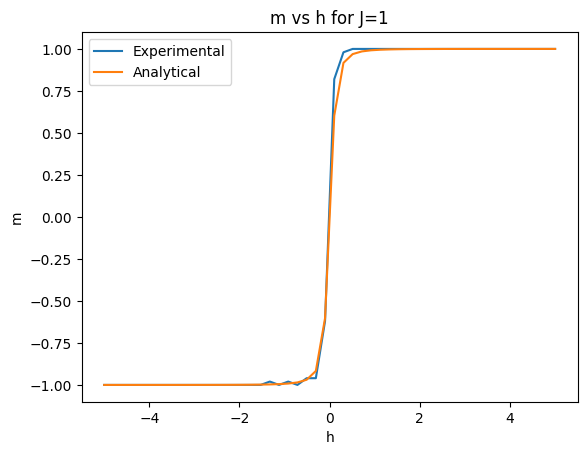

In [34]:
h_values = np.linspace(-5,5,30)
avg_magnetization = np.zeros(30)
for i,h in enumerate(h_values):
    monte_carlo = Icing_model(100,1,h)
    final_config = monte_carlo.simulate(500)
    # print(np.sum(final_config))
    avg_magnetization[i] = np.sum(final_config)/100

plt.plot(h_values,avg_magnetization,label="Experimental")
avg_magnetization_analytical = np.sinh(h_values)/(np.sqrt((np.cosh(h_values))**2 - 2*np.exp(-2)*np.sinh(2)))
plt.plot(h_values,avg_magnetization_analytical,label="Analytical")
plt.xlabel("h")
plt.ylabel("m")
plt.title("m vs h for J=1")
plt.legend() 
plt.show()      


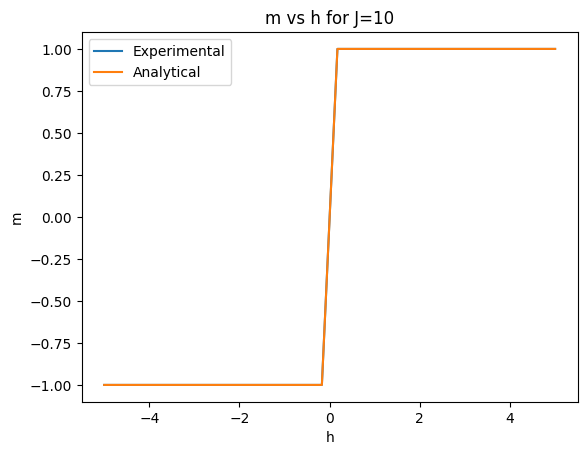

In [36]:
h_values = np.linspace(-5,5,30)
avg_magnetization = np.zeros(30)
for i,h in enumerate(h_values):
    monte_carlo = Icing_model(100,10,h)
    final_config = monte_carlo.simulate(500)
    avg_magnetization[i] = np.sum(final_config)/100

plt.plot(h_values,avg_magnetization,label="Experimental")
avg_magnetization_analytical = np.sinh(h_values)/(np.sqrt((np.cosh(h_values))**2 - 2*np.exp(-20)*np.sinh(20)))
plt.plot(h_values,avg_magnetization_analytical,label="Analytical")
plt.xlabel("h")
plt.ylabel("m")
plt.title("m vs h for J=10") 
plt.legend()
plt.show()  